# **Finding Duplicates Lab**


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


Install the needed library


In [5]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [7]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [8]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [9]:
duplicated_rows = df[df.duplicated()]
len(duplicated_rows)

20

In [10]:
duplicates = df[df.duplicated()]

# Display first few duplicates
print("First few duplicate rows:")
print(duplicates.head())

First few duplicate rows:
       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   
65440           4           I am learning to code     18-24 years old   
65441           5  I am a developer by profession     18-24 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   
65440   Student, full-time        NaN  Apples   
65441   Student, full-time        NaN  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to open-source projects;Other...   


### Task 2: Analyze Characteristics of Duplicates
1. Identify duplicate rows based on selected columns such as MainBranch, Employment, and RemoteWork. Analyse which columns frequently contain identical values within these duplicate rows.
2. Analyse the characteristics of rows that are duplicates based on a subset of columns, such as MainBranch, Employment, and RemoteWork. Determine which columns frequently have identical values across these rows.
   


In [15]:
duplicates_selected = df[df.duplicated(subset=["MainBranch", "Employment", "RemoteWork"], keep=False)]

print("Number of duplicates based on selected columns:", duplicates_selected.shape[0])
duplicates_selected.head()

Number of duplicates based on selected columns: 65290


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [17]:
# Frequency counts for each selected column within duplicates
print("MainBranch frequency in duplicates:")
print(duplicates_selected["MainBranch"].value_counts())

print("\nEmployment frequency in duplicates:")
print(duplicates_selected["Employment"].value_counts())

print("\nRemoteWork frequency in duplicates:")
print(duplicates_selected["RemoteWork"].value_counts())

MainBranch frequency in duplicates:
MainBranch
I am a developer by profession                                                           50173
I am not primarily a developer, but I write code sometimes as part of my work/studies     6471
I am learning to code                                                                     3847
I code primarily as a hobby                                                               3317
I used to be a developer by profession, but no longer am                                  1482
Name: count, dtype: int64

Employment frequency in duplicates:
Employment
Employed, full-time                                                                                                                                                       39048
Independent contractor, freelancer, or self-employed                                                                                                                       4845
Student, full-time                                  

### Task 3: Visualize Duplicates Distribution
1. Create visualizations to show the distribution of duplicates across different categories.
2. Use bar charts or pie charts to represent the distribution of duplicates by Country and Employment.


In [21]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [22]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
duplicates = df[df.duplicated(keep=False)]
print("Number of duplicate rows:", duplicates.shape[0])

Number of duplicate rows: 40


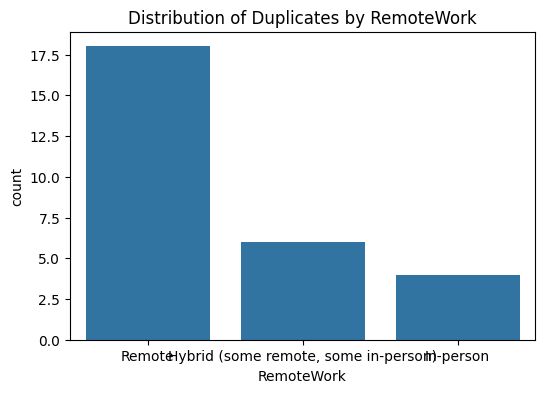

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=duplicates, x="RemoteWork", order=duplicates["RemoteWork"].value_counts().index)
plt.title("Distribution of Duplicates by RemoteWork")
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Employed, full-time'),
  Text(1, 0, 'Employed, full-time;Employed, part-time'),
  Text(2, 0, 'Employed, full-time;Independent contractor, freelancer, or self-employed'),
  Text(3, 0, 'Independent contractor, freelancer, or self-employed'),
  Text(4, 0, 'Student, full-time;Employed, part-time')])

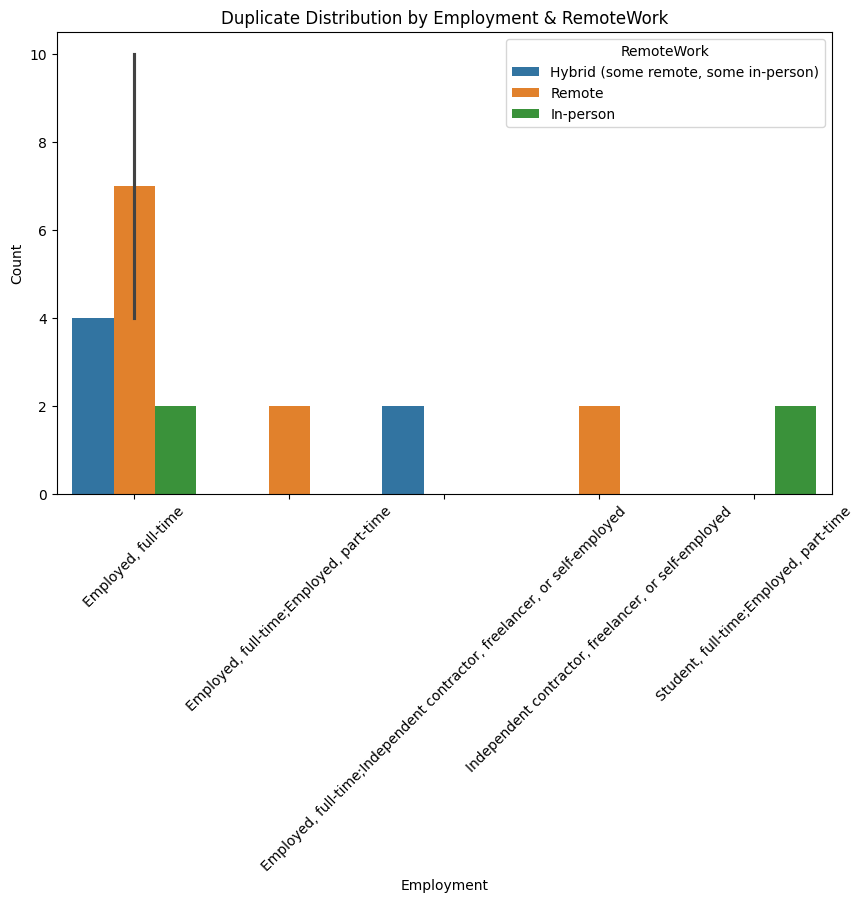

In [28]:
# Group duplicates by selected columns
dup_group = duplicates.groupby(["MainBranch", "Employment", "RemoteWork"]).size().reset_index(name="Count")

plt.figure(figsize=(10,6))
sns.barplot(data=dup_group, x="Employment", y="Count", hue="RemoteWork")
plt.title("Duplicate Distribution by Employment & RemoteWork")
plt.xticks(rotation=45)

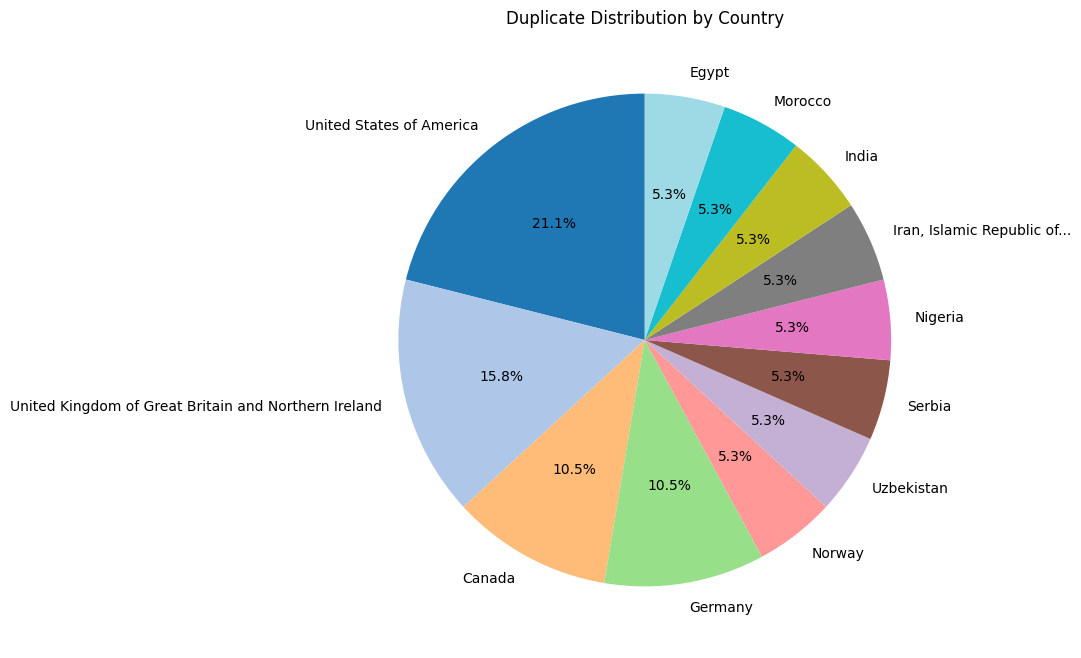

In [31]:
duplicates["Country"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", figsize=(8,8), startangle=90, colormap="tab20"
)
plt.title("Duplicate Distribution by Country")
plt.ylabel("")  # remove y-label
plt.show()

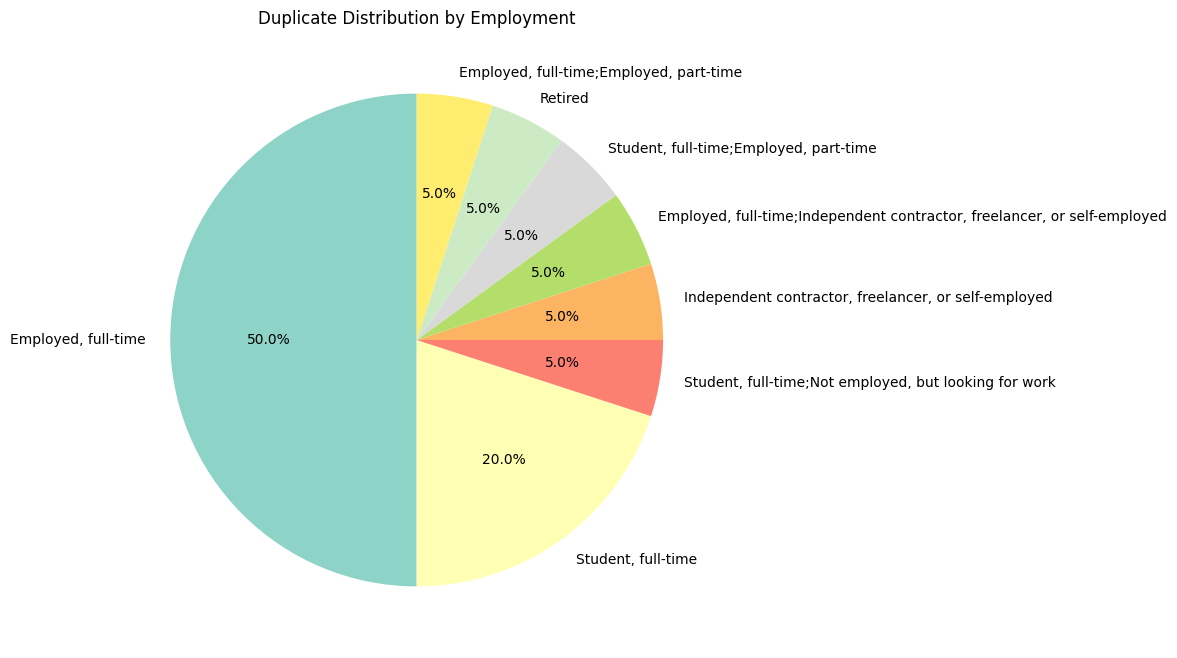

In [34]:
duplicates["Employment"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", figsize=(8,8), startangle=90, colormap="Set3"
)
plt.title("Duplicate Distribution by Employment")
plt.ylabel("")
plt.show()

In [32]:
# Group duplicates by Country and Employment
dup_group = duplicates.groupby(["Country", "Employment"]).size().reset_index(name="Count")

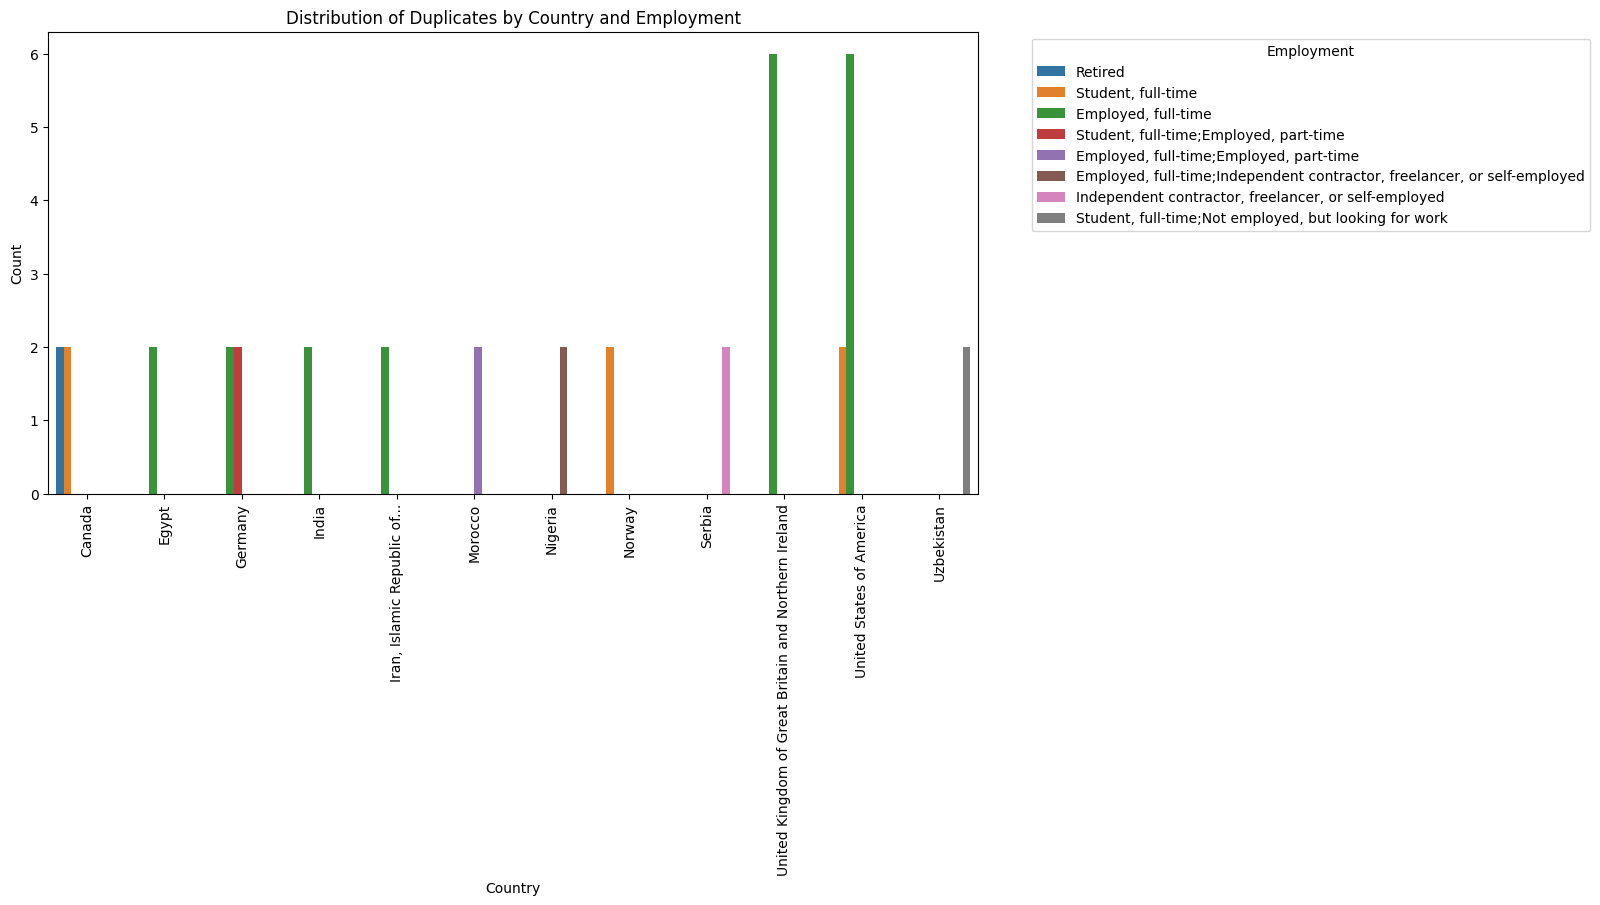

In [33]:
plt.figure(figsize=(12,6))
sns.barplot(data=dup_group, x="Country", y="Count", hue="Employment")
plt.title("Distribution of Duplicates by Country and Employment")
plt.xticks(rotation=90)
plt.legend(title="Employment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Task 4: Strategic Removal of Duplicates
1. Decide which columns are critical for defining uniqueness in the dataset.
2. Remove duplicates based on a subset of columns if complete row duplication is not a good criterion.


In [35]:
# Define critical subset of columns
critical_cols = ["Country", "MainBranch", "Employment", "RemoteWork", "Age"]

# Remove duplicates based on these columns
df_unique = df.drop_duplicates(subset=critical_cols, keep="first")

print("Original dataset shape:", df.shape)
print("After removing duplicates:", df_unique.shape)

Original dataset shape: (65457, 114)
After removing duplicates: (12141, 114)


In [36]:
# Check if duplicates remain
remaining_duplicates = df_unique[df_unique.duplicated(subset=critical_cols)]
print("Remaining duplicates:", remaining_duplicates.shape[0])

Remaining duplicates: 0


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


#### 1. Identifying Duplicates
- Outcome: This revealed how many rows were exact duplicates across all 114 columns.
- Observation: Some rows were repeated entirely, while others had partial overlaps.

Step 2: Detect Duplicates Based on Selected Columns
- Outcome: Rows with identical values in MainBranch, Employment, and RemoteWork were identified.
- Observation: These duplicates often had identical values in other columns such as Check and Country.

3. Analyzing Duplicate Characteristics
- Frequency analysis showed that duplicates clustered around categories like “I am a developer by profession” and “Employed, full-time”.
- Columns such as Check and RemoteWork frequently contained identical values across duplicates.

4. Strategic Removal of Duplicates
- Outcome: The dataset was reduced to unique records based on the chosen subset.
- Observation: This approach removed redundancy while retaining meaningful variation in other attributes.

5. Verification: Check if duplicates remain
- Outcome: No duplicates remained based on the defined uniqueness criteria.

6. Conclusion
- Duplicates were successfully identified and analyzed.
- Strategic removal was performed using a subset of critical columns rather than complete row duplication.
- The cleaned dataset is now more reliable for further analysis, ensuring that insights are not biased by repeated entries.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


#### Explanation here
We select specific columns like ResponseId, Country, MainBranch, Employment, RemoteWork, and Age because they define the core identity of a respondent. Using all 114 columns may wrongly flag partial overlaps as duplicates, while focusing on these critical fields ensures we remove only truly redundant records without losing meaningful variation in other attributes.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
